theta_abs = [0.60565999 0.37316012 0.00173492 0.00527164 0.80842119]


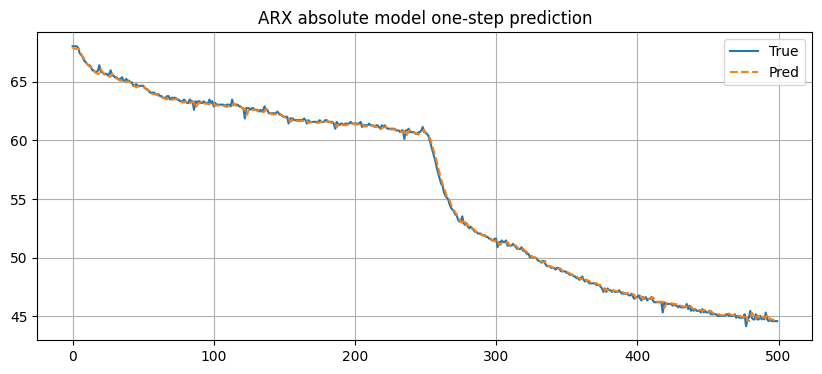

Estimated equilibrium input for 59 °C: 63.0
Mean steady temperature at u_eq: 59.01043751947654


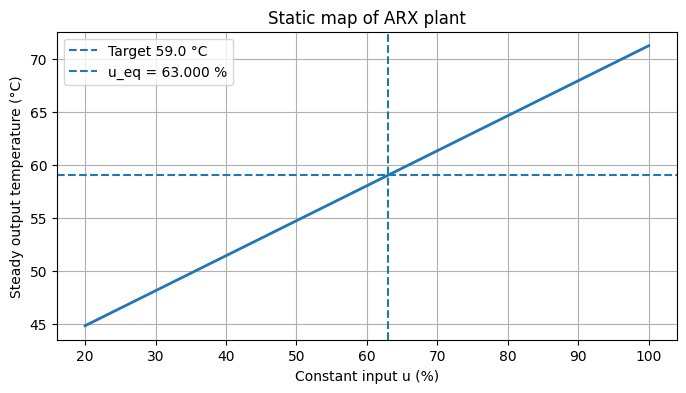

Using operating point:
y_ss = 59.0
u_ss = 63.0
Check mean of last 100 samples at corrected u_ss: 59.01043751947654


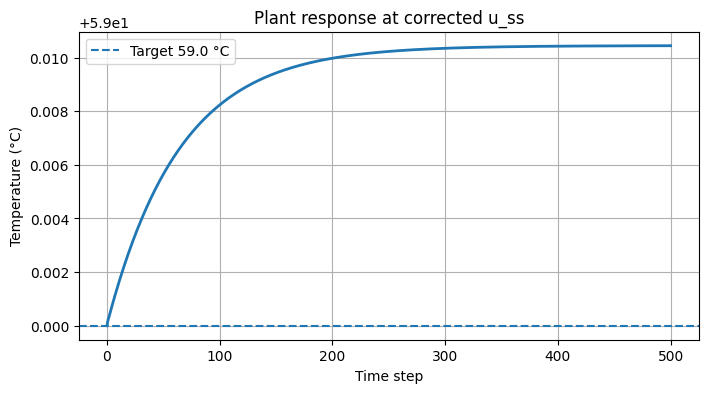

A_strejc = [[0.98540172]]
B_strejc = [[0.01640409]]
A_koop shape: (4, 4)
B_koop shape: (4, 1)
||B_koop|| = 1.0675967183129822
Koopman equilibrium error norm: 3.7133263438596367
z_eq = [0. 0. 0. 1.]
z_next = [0.02999908 0.09790911 3.71191412 1.        ]
dumin = -43.0
dumax = 37.0
Simulating T0 = 45 °C
Simulating T0 = 50 °C
Simulating T0 = 55 °C
Simulating T0 = 58 °C
Simulating T0 = 60 °C
Simulating T0 = 62 °C
Simulating T0 = 66 °C
Simulating T0 = 68 °C


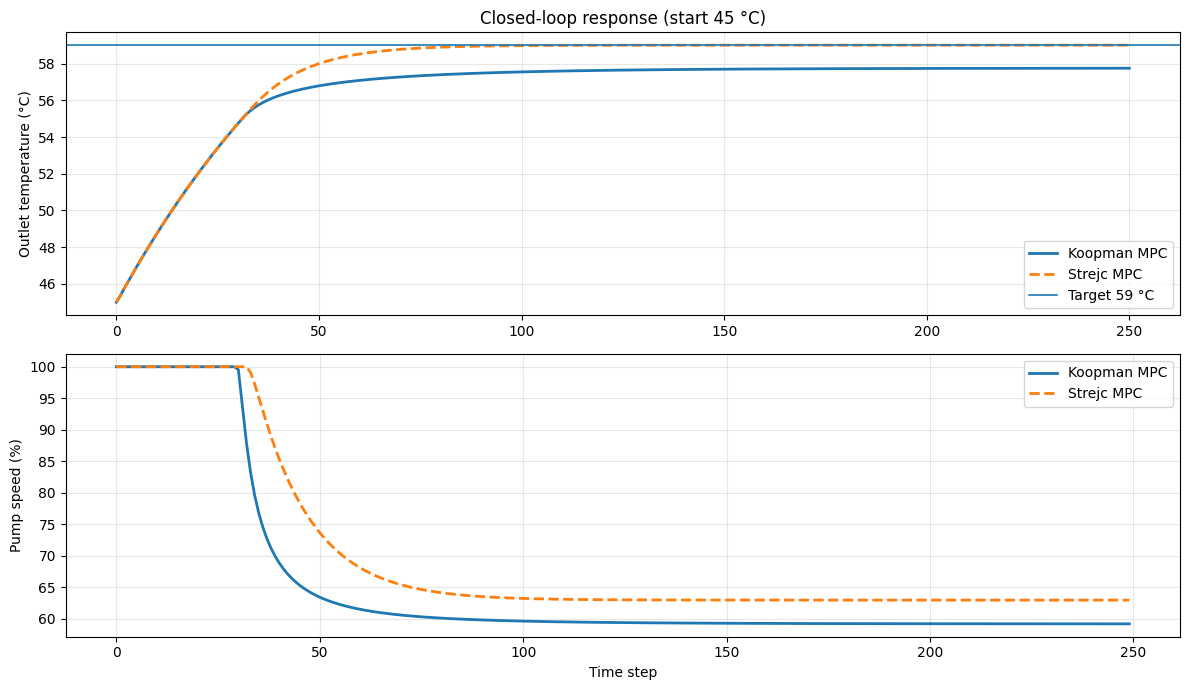

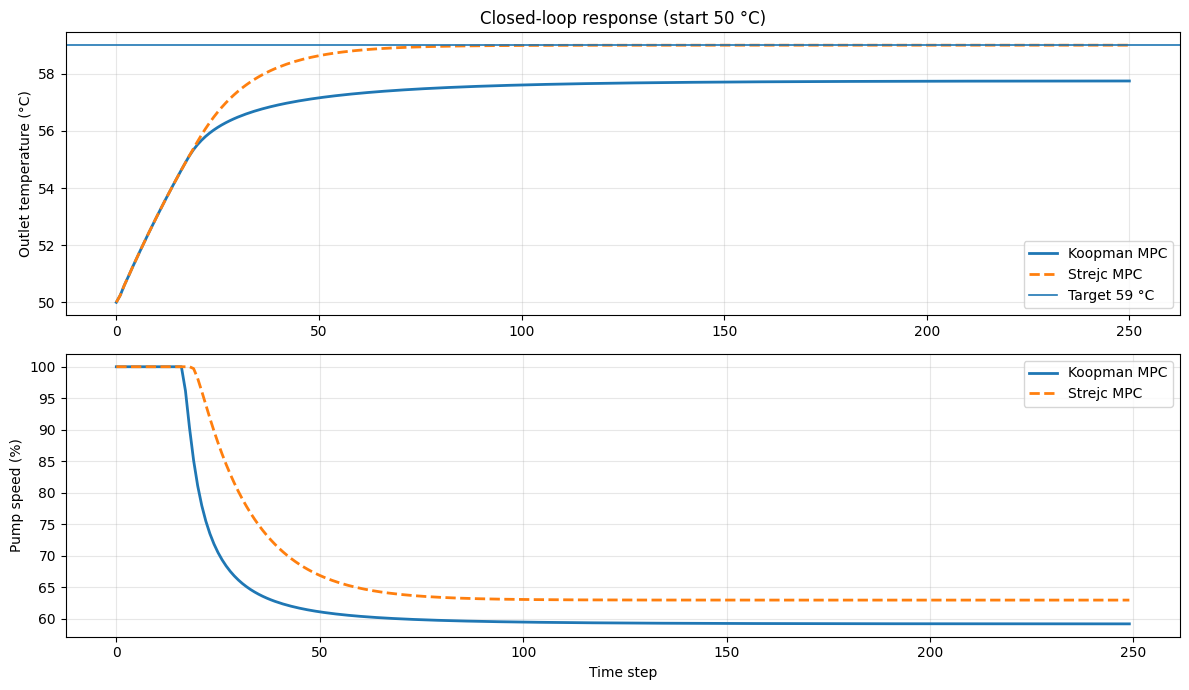

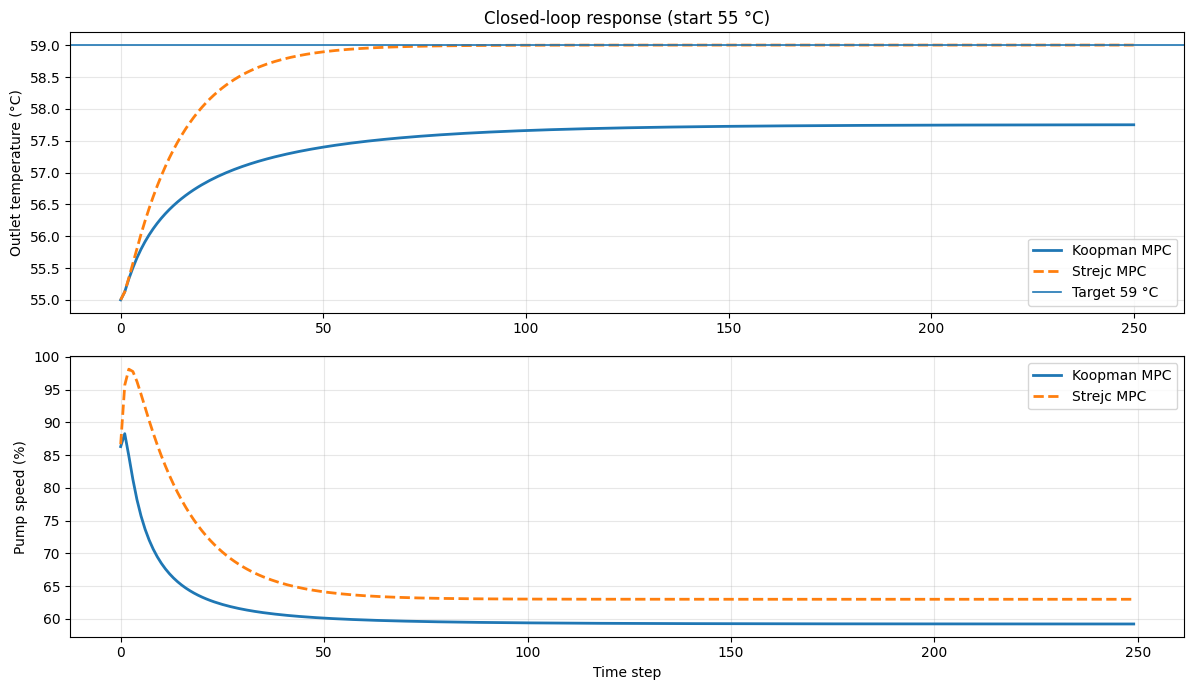

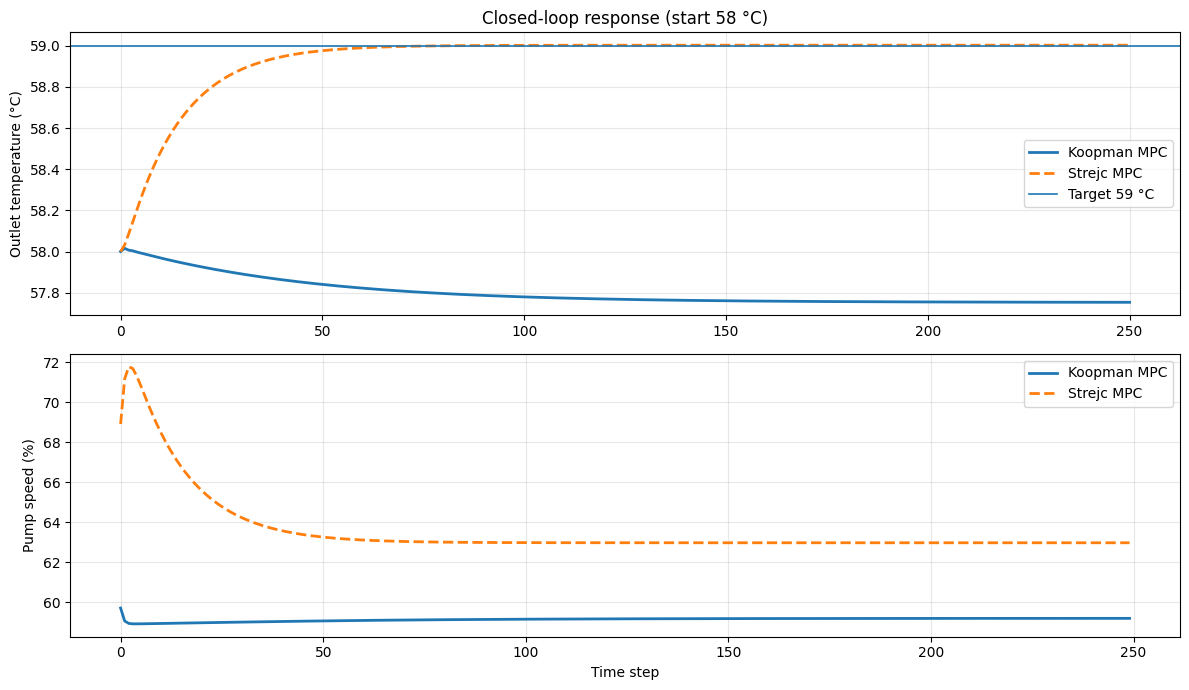

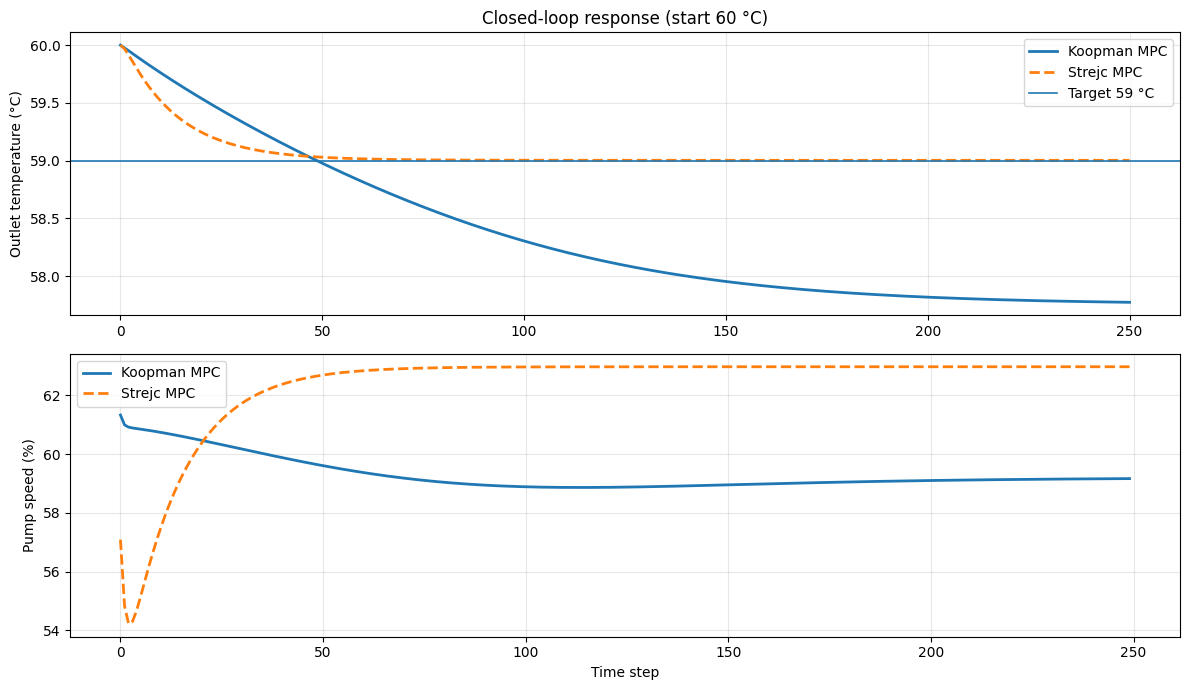

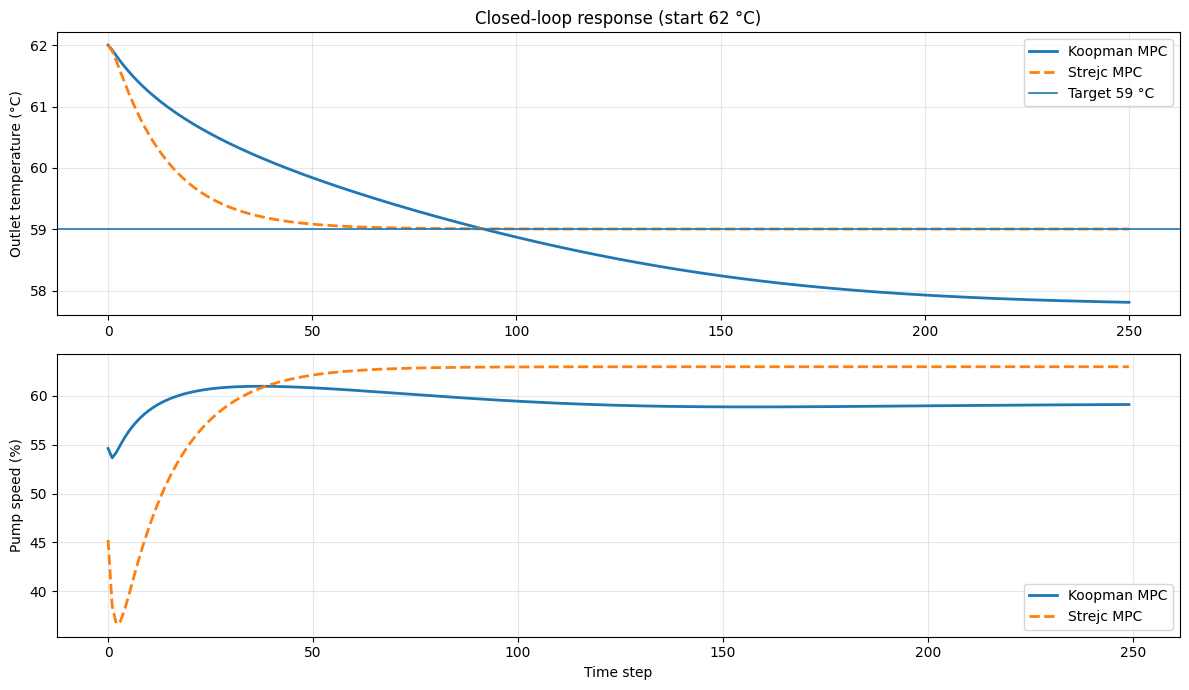

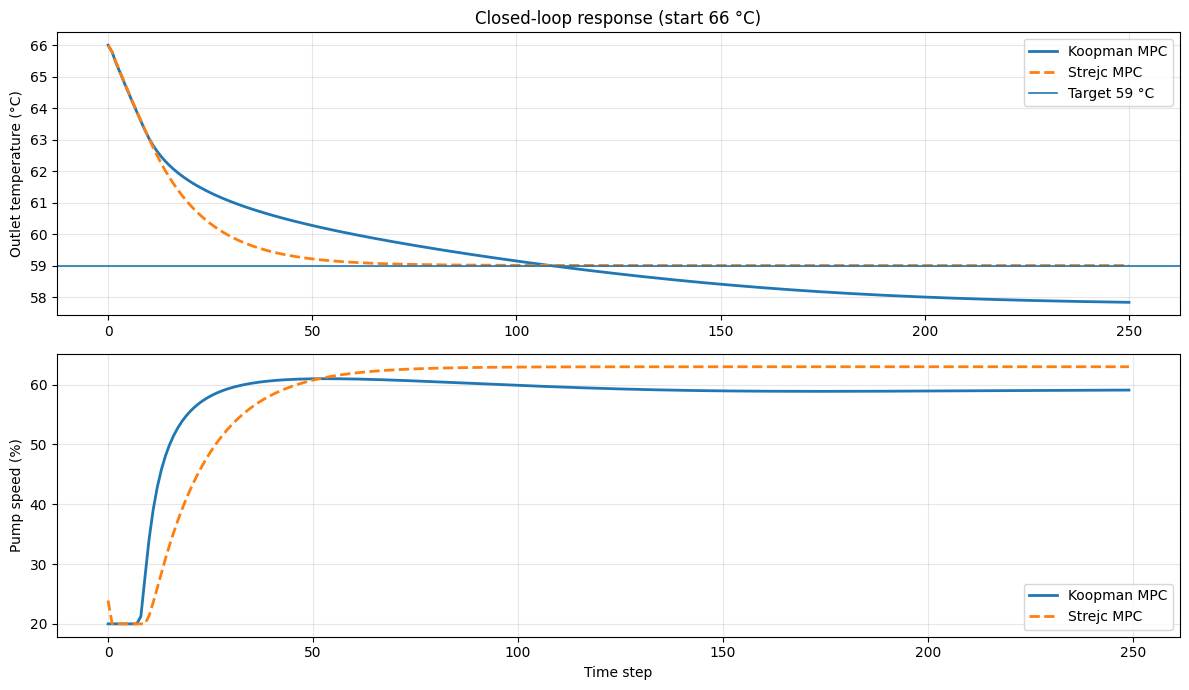

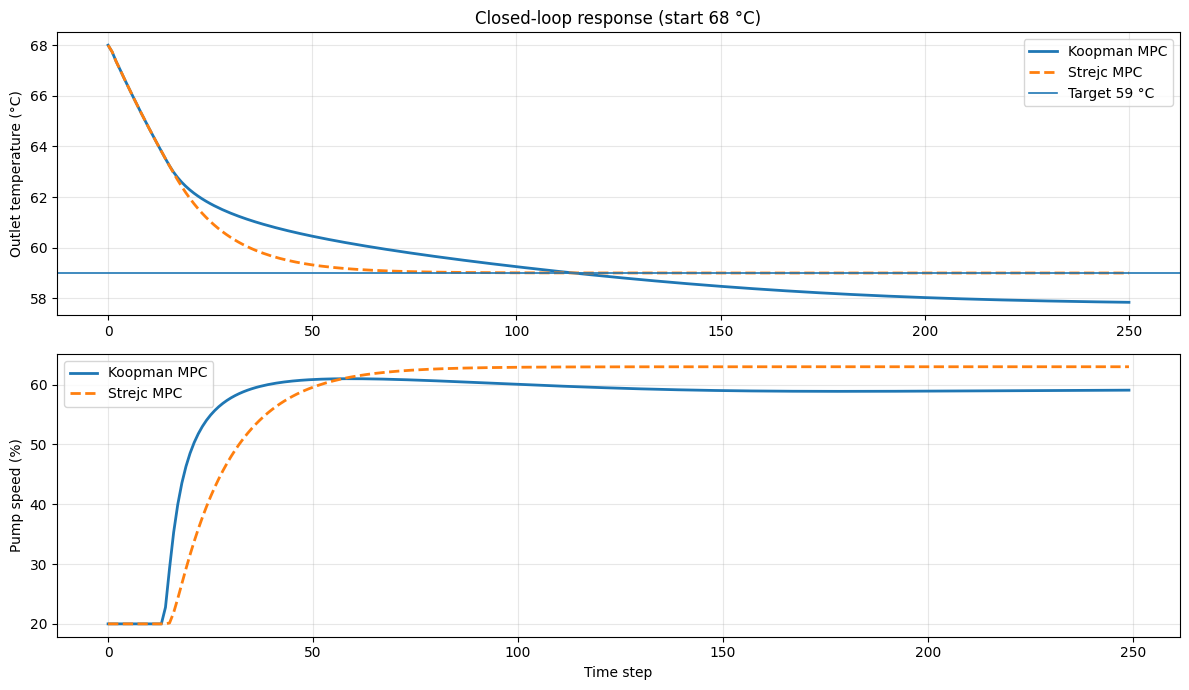

   T0    RMSE_K    RMSE_S       IAE_K       IAE_S         Obj_K         Obj_S
0  45  3.589850  3.331809  608.275745  329.693803  34601.166055  30516.518571
1  50  2.346820  1.906704  467.362026  171.780946  15231.945103  10924.354283
2  55  1.578755  0.722772  376.103339   59.948923   6510.413812   1927.140143
3  58  1.201538  0.180412  299.937944   15.138261   3795.868503    120.063961
4  60  0.897234  0.181197  203.651811   15.536556   2186.736350    121.133656
5  62  1.081216  0.542767  229.317594   45.470460   3102.178621   1086.833069
6  66  1.646211  1.340282  289.048376  114.125740   7961.380497   6067.373843
7  68  2.061927  1.832221  329.918280  161.235845  12343.655802  10513.762904

Extra checks:
u_ss = 63.0
y_ss = 59.0
Target = 59.0
Mean of last 100 samples with constant corrected u_ss: 59.01043751947654


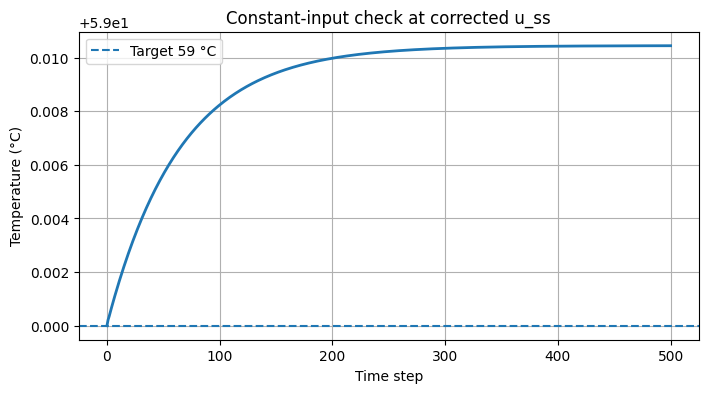

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import cont2discrete
import cvxpy as cp
import os

# ============================================================
# PATH + DATA
# ============================================================
SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"

train_data = loadmat(os.path.join(SEM2025_DIR, "data", "train_data.mat"))
test_data = loadmat(os.path.join(SEM2025_DIR, "data", "test_data.mat"))

Ytrain = train_data["Ytrain"].reshape(-1)
Utrain = train_data["Utrain"].reshape(-1)

Ytest = test_data["Ytest"].reshape(-1)
Utest = test_data["Utest"].reshape(-1)

# physical target you want to track
y_target = 59.0


# ============================================================
# ABSOLUTE ARX MODEL
# y(k+1) = a1*y(k) + a2*y(k-1) + b1*u(k) + b2*u(k-1) + c
# ============================================================
def make_arx_abs_data(Y, U):
    X = []
    T = []
    for k in range(1, len(Y) - 1):
        X.append([Y[k], Y[k - 1], U[k], U[k - 1], 1.0])
        T.append(Y[k + 1])
    return np.array(X), np.array(T)


Xtr, Ttr = make_arx_abs_data(Ytrain, Utrain)
Xte, Tte = make_arx_abs_data(Ytest, Utest)

theta_abs, *_ = np.linalg.lstsq(Xtr, Ttr, rcond=None)
print("theta_abs =", theta_abs)


# one-step test
pred_te = Xte @ theta_abs
plt.figure(figsize=(10, 4))
plt.plot(Tte[:500], label="True")
plt.plot(pred_te[:500], "--", label="Pred")
plt.grid(True)
plt.legend()
plt.title("ARX absolute model one-step prediction")
plt.show()


class ARXPlantAbs:
    def __init__(self, theta):
        self.theta = theta
        self.yk = None
        self.ykm1 = None
        self.ukm1 = None

    def reset(self, y0, u0):
        self.yk = float(y0)
        self.ykm1 = float(y0)
        self.ukm1 = float(u0)

    def step(self, uk):
        x = np.array([self.yk, self.ykm1, uk, self.ukm1, 1.0])
        y_next = float(x @ self.theta)

        self.ykm1 = self.yk
        self.yk = y_next
        self.ukm1 = float(uk)

        return y_next


def rollout_const_u_abs(theta, y0, u_const, n=500):
    plant = ARXPlantAbs(theta)
    plant.reset(y0, u_const)

    ys = [y0]
    for _ in range(n):
        ys.append(plant.step(u_const))
    return np.array(ys)


def final_temp_for_u(theta, y0, u_const, n=500, n_avg=100):
    ys = rollout_const_u_abs(theta, y0, u_const, n=n)
    return np.mean(ys[-n_avg:])


# ============================================================
# FIND CORRECTED EQUILIBRIUM INPUT FOR TARGET 59 °C
# ============================================================
u_grid = np.linspace(20, 100, 801)
y_final = np.array([final_temp_for_u(theta_abs, y_target, u, n=500, n_avg=100) for u in u_grid])

idx = np.argmin(np.abs(y_final - y_target))
u_eq = float(u_grid[idx])

print("Estimated equilibrium input for 59 °C:", u_eq)
print("Mean steady temperature at u_eq:", y_final[idx])

plt.figure(figsize=(8, 4))
plt.plot(u_grid, y_final, linewidth=2)
plt.axhline(y_target, linestyle="--", label=f"Target {y_target} °C")
plt.axvline(u_eq, linestyle="--", label=f"u_eq = {u_eq:.3f} %")
plt.grid(True)
plt.xlabel("Constant input u (%)")
plt.ylabel("Steady output temperature (°C)")
plt.legend()
plt.title("Static map of ARX plant")
plt.show()

# use target-centered operating point
y_ss = y_target
u_ss = u_eq

print("Using operating point:")
print("y_ss =", y_ss)
print("u_ss =", u_ss)

# verify corrected equilibrium
ys_test = rollout_const_u_abs(theta_abs, y_ss, u_ss, n=500)
print("Check mean of last 100 samples at corrected u_ss:", np.mean(ys_test[-100:]))

plt.figure(figsize=(8, 4))
plt.plot(ys_test, linewidth=2)
plt.axhline(y_ss, linestyle="--", label=f"Target {y_ss} °C")
plt.grid(True)
plt.legend()
plt.title("Plant response at corrected u_ss")
plt.xlabel("Time step")
plt.ylabel("Temperature (°C)")
plt.show()


# ============================================================
# DEVIATION VARIABLES
# ============================================================
dYtrain = Ytrain - y_ss
dUtrain = Utrain - u_ss

dYtest = Ytest - y_ss
dUtest = Utest - u_ss


# ============================================================
# STREJC MODEL IN DEVIATION VARIABLES
# ============================================================
gain = 1.1237
tau = 68.0
Ts = 1.0

A_c = np.array([[-1.0 / tau]])
B_c = np.array([[gain / tau]])
C_c = np.array([[1.0]])
D_c = np.array([[0.0]])

A_strejc, B_strejc, C_strejc, D_strejc, _ = cont2discrete(
    (A_c, B_c, C_c, D_c), Ts, method="zoh"
)

A_strejc = np.array(A_strejc, dtype=float)
B_strejc = np.array(B_strejc, dtype=float)
C_strejc = np.array(C_strejc, dtype=float)

print("A_strejc =", A_strejc)
print("B_strejc =", B_strejc)


# ============================================================
# SIMPLE KOOPMAN / LIFTED DEVIATION MODEL
# ============================================================
def lift_dy(dy):
    return np.array([dy, dy**2, dy**3, 1.0], dtype=float)


Z = []
Zp = []
DU = []

for k in range(len(dYtrain) - 1):
    zk = lift_dy(dYtrain[k])
    zkp1 = lift_dy(dYtrain[k + 1])
    duk = dUtrain[k]

    Z.append(zk)
    Zp.append(zkp1)
    DU.append([duk])

Z = np.array(Z)
Zp = np.array(Zp)
DU = np.array(DU)

Phi = np.hstack([Z, DU])
Theta, *_ = np.linalg.lstsq(Phi, Zp, rcond=None)

nz = Z.shape[1]
# A_koop = Theta[:nz, :].T
# B_koop = Theta[nz:, :].T

# print("A_koop shape:", A_koop.shape)
# print("B_koop shape:", B_koop.shape)
# print("||B_koop|| =", np.linalg.norm(B_koop))

DATA_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\ws2025\data"

A_koop = np.load(os.path.join(DATA_DIR, "A_wC_all.npy"))
B_koop = np.load(os.path.join(DATA_DIR, "B_wC_all.npy"))
C_koop = np.load(os.path.join(DATA_DIR, "C_wC_all.npy"))

print("A_koop:", A_koop.shape)
print("B_koop:", B_koop.shape)
print("C_koop:", C_koop.shape)

# diagnostic: check whether zero deviation is equilibrium
z_eq = lift_dy(0.0).reshape(-1, 1)
z_next = A_koop @ z_eq + B_koop @ np.array([[0.0]])
print("Koopman equilibrium error norm:", np.linalg.norm(z_next - z_eq))
print("z_eq =", z_eq.ravel())
print("z_next =", z_next.ravel())


# ============================================================
# MPC FUNCTIONS
# ============================================================
def mpc_strejc_dev(
    A, B, C, x0, yref,
    N=20, Qy=10.0, Qu=0.1, Qdu=0.1,
    dumin=None, dumax=None, du_prev=0.0
):
    nx = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0

    yref = np.array([[float(yref)]])

    for k in range(N):
        constraints += [X[:, [k + 1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        objective += Qy * cp.sum_squares(yk - yref)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if k == 0:
            objective += Qdu * cp.sum_squares(U[:, [k]] - du_prev)
        else:
            objective += Qdu * cp.sum_squares(U[:, [k]] - U[:, [k - 1]])

        if dumin is not None:
            constraints += [U[:, [k]] >= dumin]
        if dumax is not None:
            constraints += [U[:, [k]] <= dumax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(du_prev)

    return float(U.value[0, 0])


def mpc_koopman_dev(
    A, B, z0, zref,
    N=20, Qz=None, Qu=0.1, Qdu=0.1,
    dumin=None, dumax=None, du_prev=0.0
):
    nz = A.shape[0]

    if Qz is None:
        Qz = np.eye(nz)

    U = cp.Variable((1, N))
    Zvar = cp.Variable((nz, N + 1))

    constraints = [Zvar[:, [0]] == z0.reshape(-1, 1)]
    objective = 0
    zref = zref.reshape(-1, 1)

    for k in range(N):
        constraints += [Zvar[:, [k + 1]] == A @ Zvar[:, [k]] + B @ U[:, [k]]]

        objective += cp.quad_form(Zvar[:, k] - zref[:, 0], Qz)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if k == 0:
            objective += Qdu * cp.sum_squares(U[:, [k]] - du_prev)
        else:
            objective += Qdu * cp.sum_squares(U[:, [k]] - U[:, [k - 1]])

        if dumin is not None:
            constraints += [U[:, [k]] >= dumin]
        if dumax is not None:
            constraints += [U[:, [k]] <= dumax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(du_prev)

    return float(U.value[0, 0])


# ============================================================
# CLOSED LOOP SETTINGS
# ============================================================
u_min = 20.0
u_max = 100.0

dumin = u_min - u_ss
dumax = u_max - u_ss

print("dumin =", dumin)
print("dumax =", dumax)

temps = [45, 50, 55, 58, 60, 62, 66, 68]
sim_length = 250

N = 30
Qy = 10.0
Qz = np.diag([10.0, 1.0, 0.1, 0.0])
Qu = 0.05
Qdu = 0.1

# because operating point is centered at 59 °C
y_ref = 0.0
z_ref = lift_dy(y_ref).reshape(-1, 1)

all_results = {}


# ============================================================
# CLOSED LOOP SIMULATION
# ============================================================
for T0 in temps:
    print(f"Simulating T0 = {T0} °C")

    # ---------------- Koopman MPC ----------------
    plant_k = ARXPlantAbs(theta_abs)
    plant_k.reset(T0, u_ss)

    dy0 = T0 - y_ss
    z0 = lift_dy(dy0).reshape(-1, 1)

    y_store_k = [T0]
    u_store_k = []
    du_store_k = []
    du_prev_k = 0.0

    for t in range(sim_length):
        du_k = mpc_koopman_dev(
            A_koop, B_koop,
            z0, z_ref,
            N=N, Qz=Qz, Qu=Qu, Qdu=Qdu,
            dumin=dumin, dumax=dumax,
            du_prev=du_prev_k
        )

        u_k = u_ss + du_k
        y_next = plant_k.step(u_k)

        dy_next = y_next - y_ss
        z0 = lift_dy(dy_next).reshape(-1, 1)

        y_store_k.append(y_next)
        u_store_k.append(u_k)
        du_store_k.append(du_k)
        du_prev_k = du_k

    # ---------------- Strejc MPC ----------------
    plant_s = ARXPlantAbs(theta_abs)
    plant_s.reset(T0, u_ss)

    x_s = np.array([[T0 - y_ss]])
    y_store_s = [T0]
    u_store_s = []
    du_store_s = []
    du_prev_s = 0.0

    for t in range(sim_length):
        du_s = mpc_strejc_dev(
            A_strejc, B_strejc, C_strejc,
            x_s, y_ref,
            N=N, Qy=Qy, Qu=Qu, Qdu=Qdu,
            dumin=dumin, dumax=dumax,
            du_prev=du_prev_s
        )

        u_s = u_ss + du_s
        y_next = plant_s.step(u_s)

        x_s = np.array([[y_next - y_ss]])

        y_store_s.append(y_next)
        u_store_s.append(u_s)
        du_store_s.append(du_s)
        du_prev_s = du_s

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "du_koop": np.array(du_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
        "du_strejc": np.array(du_store_s),
    }


# ============================================================
# PLOTS
# ============================================================
for T0 in temps:
    res = all_results[T0]

    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(y_target, linewidth=1.2, label="Target 59 °C")
    plt.grid(True, alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0} °C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# SUMMARY
# ============================================================
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - y_target
    e_s = res["y_strejc"][:-1] - y_target

    rmse_k = np.sqrt(np.mean(e_k**2))
    rmse_s = np.sqrt(np.mean(e_s**2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    du_k = res["u_koop"] - u_ss
    du_s = res["u_strejc"] - u_ss

    obj_k = np.sum(Qy * e_k**2 + Qu * du_k**2)
    obj_s = np.sum(Qy * e_s**2 + Qu * du_s**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print(summary_df)


# ============================================================
# EXTRA CHECKS
# ============================================================
print("\nExtra checks:")
print("u_ss =", u_ss)
print("y_ss =", y_ss)
print("Target =", y_target)

ys_check = rollout_const_u_abs(theta_abs, y_target, u_ss, n=500)
print("Mean of last 100 samples with constant corrected u_ss:", np.mean(ys_check[-100:]))

plt.figure(figsize=(8, 4))
plt.plot(ys_check, linewidth=2)
plt.axhline(y_target, linestyle="--", label="Target 59 °C")
plt.grid(True)
plt.legend()
plt.title("Constant-input check at corrected u_ss")
plt.xlabel("Time step")
plt.ylabel("Temperature (°C)")
plt.show()